In [537]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

In [538]:
pd.__version__

'3.0.2'

In [539]:
np.__version__

'2.4.4'

In [540]:
import matplotlib
matplotlib.__version__

'3.11.1'

## 1. Load the data

In [541]:
df = pd.read_csv("../data/brain_stroke.csv")

print(df.shape)
df.head()

(4981, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,NaN,81.0,0.0,0.0,Yes,Private,Urban,NaN,29.0,formerly smoked,1


In [542]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4976 non-null   str    
 1   age                4981 non-null   float64
 2   hypertension       4980 non-null   float64
 3   heart_disease      4979 non-null   float64
 4   ever_married       4975 non-null   str    
 5   work_type          4971 non-null   str    
 6   Residence_type     4973 non-null   str    
 7   avg_glucose_level  4975 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4976 non-null   str    
 10  stroke             4981 non-null   int64  
dtypes: float64(5), int64(1), str(5)
memory usage: 428.2 KB


In [543]:
df.isnull().sum()

gender                5
age                   0
hypertension          1
heart_disease         2
ever_married          6
work_type            10
Residence_type        8
avg_glucose_level     6
bmi                   0
smoking_status        5
stroke                0
dtype: int64

In [544]:
from sklearn.model_selection import train_test_split

In [545]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["stroke"]
)

In [546]:
train_df.to_csv("../data/brain_stroke_train.csv", index=False)
test_df.to_csv("../data/brain_stroke_test.csv", index=False)

In [547]:
print("Original:", df.shape)
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Original: (4981, 11)
Train: (3984, 11)
Test: (997, 11)


In [548]:
df_train = pd.read_csv("../data/brain_stroke_train.csv")
df_test  = pd.read_csv("../data/brain_stroke_test.csv")

In [549]:
#2. try .head()
df_train.head()
# df_train.info()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,24.0,0.0,0.0,No,Private,Rural,187.99,24.9,smokes,0
1,Male,3.0,0.0,0.0,No,children,Rural,86.38,22.8,Unknown,0
2,Female,69.0,0.0,0.0,Yes,Private,Urban,111.48,37.0,smokes,0
3,Female,46.0,0.0,0.0,Yes,Private,Urban,127.75,30.5,never smoked,0
4,Male,52.0,1.0,0.0,Yes,Private,Rural,100.71,37.0,never smoked,0


In [550]:
#1. get the shape (rows, columns)
print(df_train.shape)  #(614 rows, 13 columns)

#2. try .head()
# df_train.head()
# df_train.info()

#3. try .describe()
# df_train.describe()

#4. check whether our data class is balanced, using value_counts(normalize=True)
df_train['stroke'].value_counts() #if you don't put normalize=True, will give you raw number

#our class is imbalanced....
#it means, we have to downsample Y, to equal N

(3984, 11)


stroke
0    3786
1     198
Name: count, dtype: int64

In [551]:
df_train['avg_glucose_level'].max()

np.float64(267.76)

In [552]:
condMaxGL = df_train['avg_glucose_level'] == 267.76
df_train[condMaxGL]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2238,Female,49.0,0.0,0.0,Yes,Private,Urban,267.76,29.3,formerly smoked,0


In [553]:
df_train.loc[2238]

gender                        Female
age                             49.0
hypertension                     0.0
heart_disease                    0.0
ever_married                     Yes
work_type                    Private
Residence_type                 Urban
avg_glucose_level             267.76
bmi                             29.3
smoking_status       formerly smoked
stroke                             0
Name: 2238, dtype: object

In [554]:
df_train['stroke'].value_counts()

stroke
0    3786
1     198
Name: count, dtype: int64

### Balance the class

- We need to balance the label in the training set, because imbalanced class affects the model during training
- If we do not balance the class, you can also try look at the SMOTE (https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) algorithm which dynamically augments data on the fly.

In [555]:
#1. set the cond = Y, and cond = N
condY = df_train.stroke == 1  #to 0 or 1
condN = df_train.stroke == 0

#2.. df[condY].sample(n = 192)
#    df[condN].sample
#    we do this many times, do whole ML thing, and do the average....
df_trainY = df_train[condY]
df_trainN = df_train[condN].sample(n=198, random_state=999)

#3. concat these two dfs
df_train = pd.concat([df_trainY, df_trainN])

df_train.stroke.value_counts()


stroke
1    198
0    198
Name: count, dtype: int64

### Label encoding

This is a useful step to do before EDA, so that categories are turned into numbers.


In [556]:
df_train.dtypes

gender                   str
age                  float64
hypertension         float64
heart_disease        float64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [557]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


In [558]:
df_train['ever_married'] = le.fit_transform(df_train['ever_married'])
df_test['ever_married']  = le.transform(df_test['ever_married'])

In [559]:
df_train['Residence_type'] = le.fit_transform(df_train['Residence_type'])
df_test['Residence_type']  = le.transform(df_test['Residence_type'])

In [560]:
df_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
63,Female,76.0,0.0,0.0,1,Private,1,57.92,27.9,formerly smoked,1
75,Female,59.0,0.0,0.0,1,Private,0,76.15,30.2,Unknown,1
133,Male,78.0,1.0,0.0,1,Self-employed,0,56.11,25.5,formerly smoked,1
136,Female,70.0,0.0,0.0,1,Self-employed,0,76.34,24.4,formerly smoked,1
154,Female,68.0,1.0,0.0,1,Self-employed,0,206.09,26.7,never smoked,1


In [561]:
df_train.stroke.value_counts()

stroke
1    198
0    198
Name: count, dtype: int64

In [562]:
cond = df_train['stroke'] == 0
df_train[cond]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1232,Male,48.0,0.0,0.0,1,Private,0,147.14,22.3,Unknown,0
3956,Female,23.0,0.0,0.0,1,Private,0,77.73,19.2,never smoked,0
340,Male,48.0,0.0,0.0,1,Private,1,72.36,34.7,smokes,0
977,Male,59.0,0.0,0.0,1,Private,0,93.90,42.2,never smoked,0
196,Male,47.0,0.0,0.0,1,Private,0,110.38,30.1,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
448,Female,72.0,0.0,0.0,1,Private,0,210.78,32.3,formerly smoked,0
1551,Male,50.0,1.0,0.0,0,Private,1,81.96,32.0,formerly smoked,0
377,Female,37.0,0.0,0.0,1,Private,0,98.12,27.5,never smoked,0
1477,Male,58.0,0.0,0.0,1,Self-employed,0,99.83,36.3,smokes,0


In [563]:
df_train.describe()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke
count,396.000000,396.000000,396.000000,396.000000,396.000000,393.000000,396.000000,396.000000
mean,54.901818,0.179293,0.121212,0.765152,0.542929,118.430204,29.366919,0.500000
std,22.509430,0.384083,0.326786,0.430364,0.508834,54.961077,6.115421,0.500633
min,0.720000,0.000000,0.000000,0.000000,0.000000,55.120000,14.200000,0.000000
25%,40.000000,0.000000,0.000000,1.000000,0.000000,78.700000,25.675000,0.000000
50%,59.000000,0.000000,0.000000,1.000000,1.000000,97.430000,29.100000,0.500000
75%,75.000000,0.000000,0.000000,1.000000,1.000000,143.430000,32.800000,1.000000
max,82.000000,1.000000,1.000000,2.000000,2.000000,263.320000,48.900000,1.000000


### One hot encoding

In [564]:
df_train.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [565]:
df_train.gender.value_counts()

gender
Female    223
Male      168
Name: count, dtype: int64

In [566]:
df_train.work_type.value_counts()

work_type
Private          226
Self-employed     82
Govt_job          52
children          32
Name: count, dtype: int64

In [567]:
df_train.smoking_status.value_counts()

smoking_status
never smoked       138
Unknown            101
formerly smoked     96
smokes              59
Name: count, dtype: int64

In [568]:
print(df_train.columns.tolist())


['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [569]:
df_train = pd.get_dummies(df_train, columns=['gender', 'work_type', 'smoking_status'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['gender', 'work_type', 'smoking_status'], drop_first=True)


In [570]:
df_train.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
63,76.0,0.0,0.0,1,1,57.92,27.9,1,False,True,False,False,True,False,False
75,59.0,0.0,0.0,1,0,76.15,30.2,1,False,True,False,False,False,False,False
133,78.0,1.0,0.0,1,0,56.11,25.5,1,True,False,True,False,True,False,False
136,70.0,0.0,0.0,1,0,76.34,24.4,1,False,False,True,False,True,False,False
154,68.0,1.0,0.0,1,0,206.09,26.7,1,False,False,True,False,False,True,False


In [571]:
df_train.Residence_type.unique()

array([1, 0, 2])

In [572]:
df_train.ever_married.unique()

array([1, 0, 2])

## 2. EDA (Exploratory Data Analysis)

In [573]:

df_train.columns

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='str')

In [574]:
df_train.dtypes

age                               float64
hypertension                      float64
heart_disease                     float64
ever_married                        int64
Residence_type                      int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
gender_Male                          bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object

In [575]:
import seaborn as sns

#1. You want to divide into categorical and numerical columns using select_dtypes
df_train.dtypes
num_col = df_train.select_dtypes(include=['int64', 'float64'])
# numcol = numcol.drop([]) #Loan_Status
cat_col = df_train.select_dtypes(exclude=['int64', 'float64'])
num_col.columns, cat_col.columns

(Index(['age', 'hypertension', 'heart_disease', 'ever_married',
        'Residence_type', 'avg_glucose_level', 'bmi', 'stroke'],
       dtype='str'),
 Index(['gender_Male', 'work_type_Private', 'work_type_Self-employed',
        'work_type_children', 'smoking_status_formerly smoked',
        'smoking_status_never smoked', 'smoking_status_smokes'],
       dtype='str'))

### Bar plots

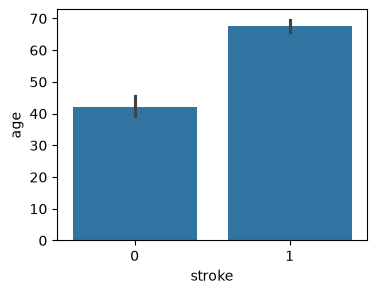

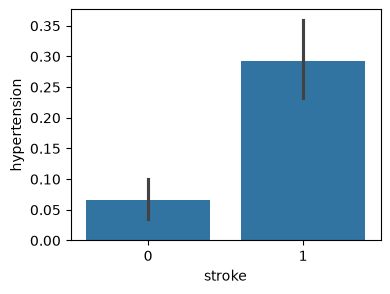

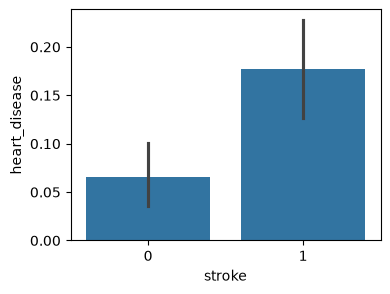

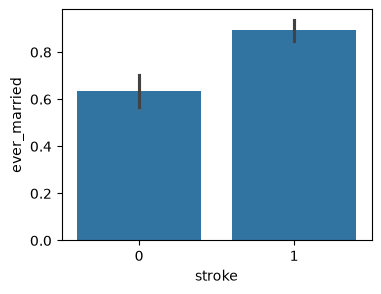

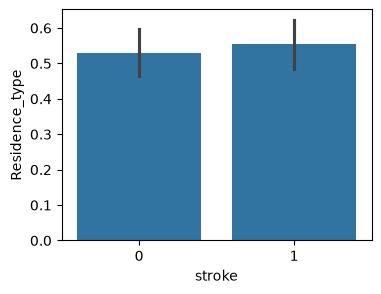

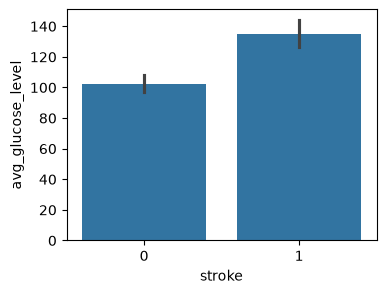

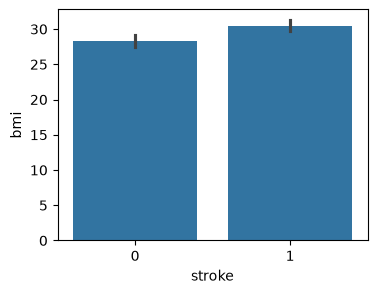

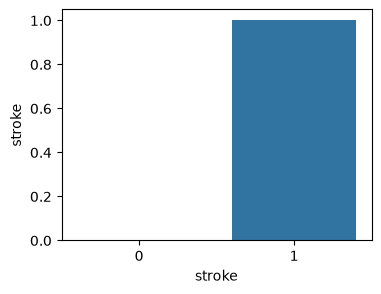

In [576]:
#make smaller figure for sns

for col in num_col.columns:
    plt.figure(figsize=(4, 3))
    sns.barplot(x = df_train['stroke'], y = df_train[col])
    plt.show()

### In case you want very nice subplot code

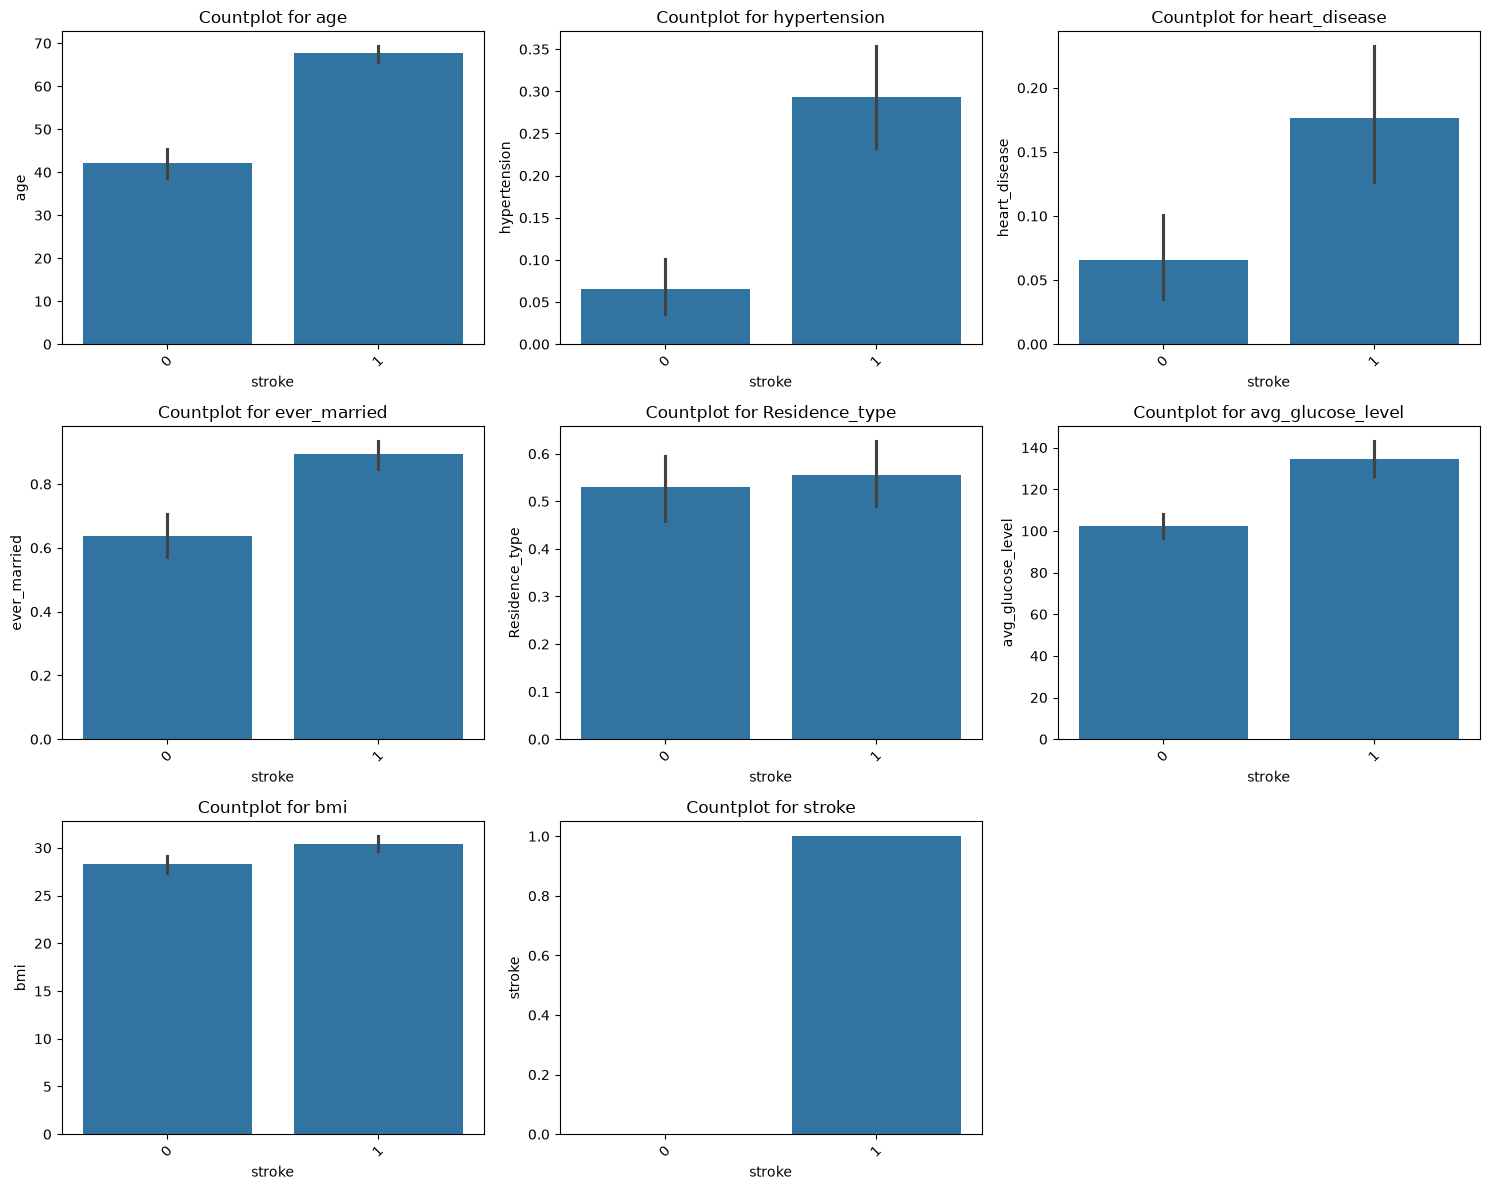

In [577]:
# Number of categorical columns
num_cols = len(num_col.columns)

# Set up the subplot grid dimensions
rows = (num_cols + 2) // 3  # Adjust the number of rows based on the number of columns
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))  # Customize the size as needed
axes = axes.flatten()  # Flatten to iterate over axes easily

# Iterate through the categorical columns and plot countplots
for i, col in enumerate(num_col.columns):
    sns.barplot(x = df_train['stroke'], y = df_train[col],ax=axes[i])

    axes[i].set_title(f'Countplot for {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels if needed

# Remove unused subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

### Countplot / Histogram

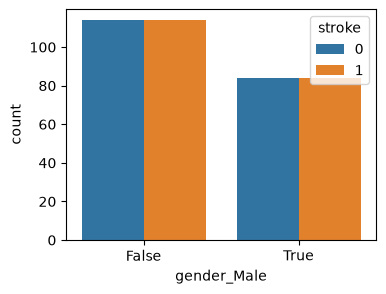

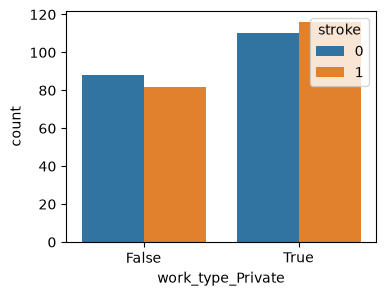

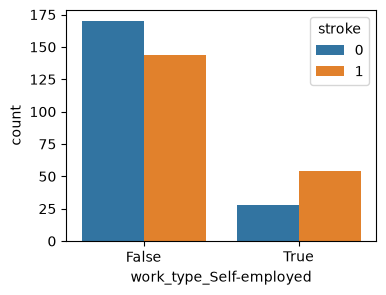

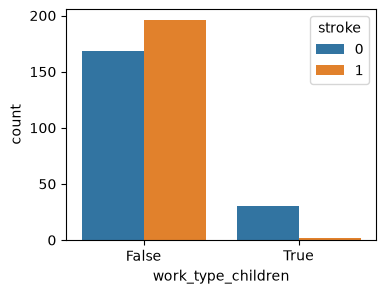

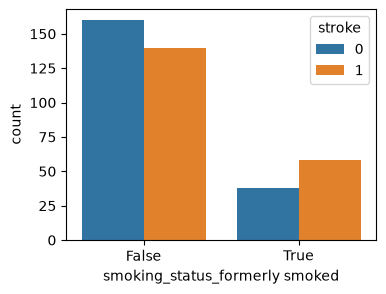

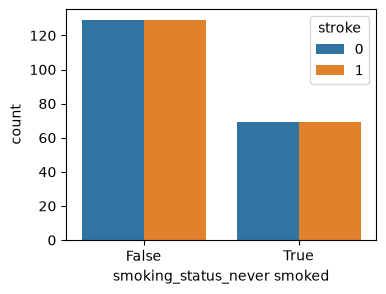

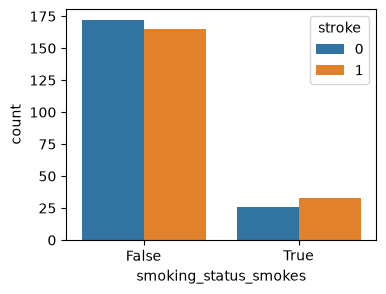

In [578]:
for col in cat_col.columns:
    plt.figure(figsize=(4, 3))
    sns.countplot(x = df_train[col], hue = df_train['stroke'])
    #similar to hue in scatterplot
    plt.show()
    # sns.countplot()  #because categorical, you need to count, not simply use the magnitude...so cannot use bar...

### Nice subplot code

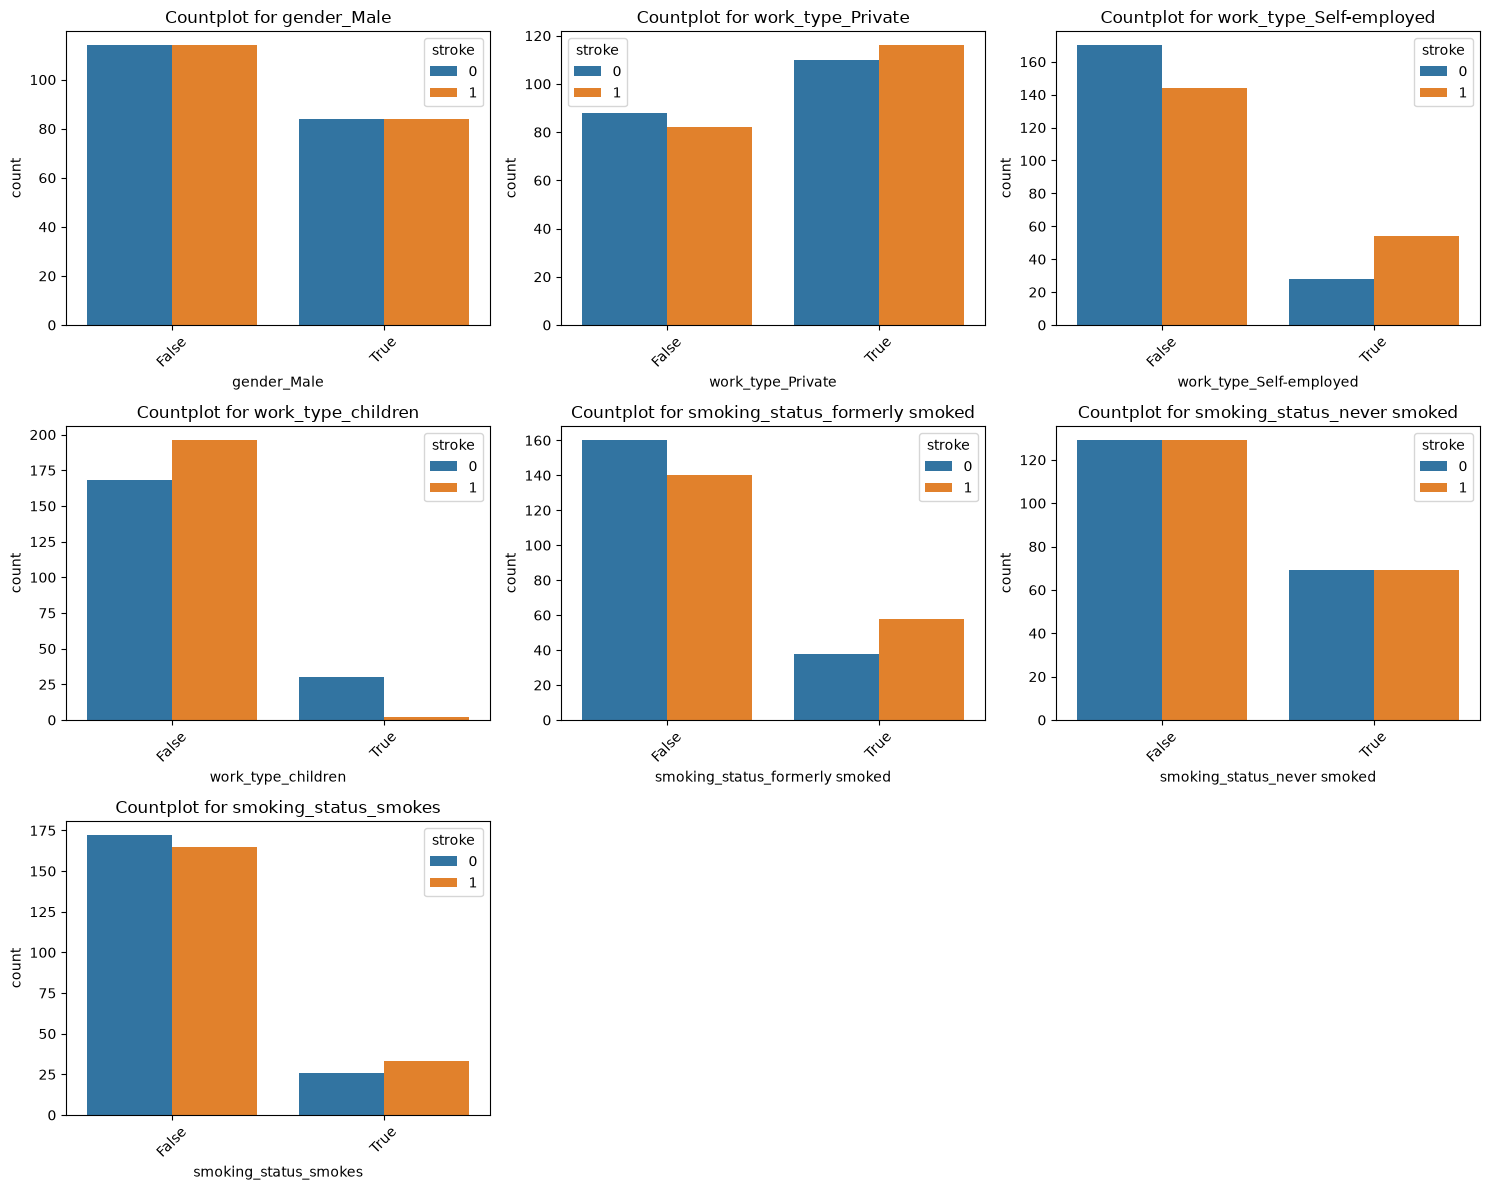

In [579]:
# Number of categorical columns
num_cols = len(cat_col.columns)

# Set up the subplot grid dimensions
rows = (num_cols + 2) // 3  # Adjust the number of rows based on the number of columns
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))  # Customize the size as needed
axes = axes.flatten()  # Flatten to iterate over axes easily

# Iterate through the categorical columns and plot countplots
for i, col in enumerate(cat_col.columns):
    sns.countplot(x=df_train[col], hue=df_train['stroke'], ax=axes[i])
    axes[i].set_title(f'Countplot for {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels if needed

# Remove unused subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

### Correlation matrix

<Axes: >

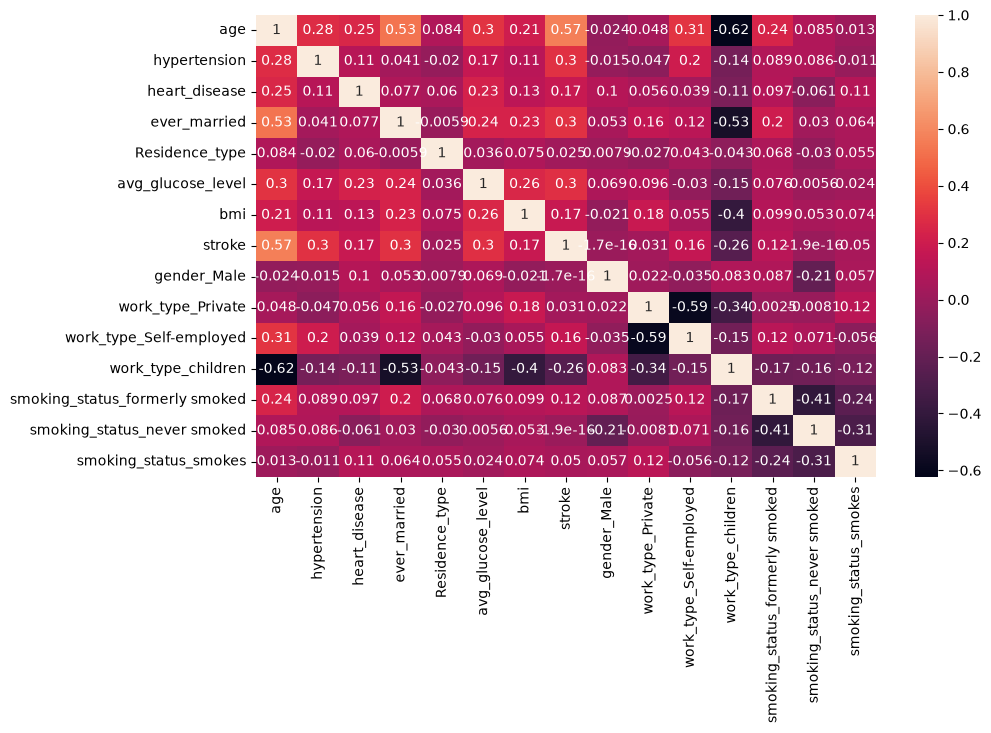

In [580]:
#change figure size
plt.figure(figsize=(10, 6))
sns.heatmap(df_train.corr(), annot=True)  #this is only for numeric values....

## 3. Feature Engineering

Skipped

## 4. Feature Selection

Since our dataset is already splitted at the dataset level, thus we do not need to hurry to select the features.  We can preprocess and then select later.

We can also use forward selection - process of starting with one feature, and slowly adding one feature at a time, until the performance does not improve by certain threshold you want.

## 5. Preprocessing

### Null values

In [581]:
#1. please check the missing value in df_train, and of course df_test
df_train.isna().sum()


age                               0
hypertension                      0
heart_disease                     0
ever_married                      0
Residence_type                    0
avg_glucose_level                 3
bmi                               0
stroke                            0
gender_Male                       0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [582]:
# Fill nulls using the median of people with the same stroke status
df_train['avg_glucose_level'] = df_train.groupby('stroke')['avg_glucose_level'].transform(lambda x: x.fillna(x.median()))
df_test['avg_glucose_level'] = df_test.groupby('stroke')['avg_glucose_level'].transform(lambda x: x.fillna(x.median()))


In [583]:
df_train.isna().sum()

age                               0
hypertension                      0
heart_disease                     0
ever_married                      0
Residence_type                    0
avg_glucose_level                 0
bmi                               0
stroke                            0
gender_Male                       0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [584]:
df_test.isna().sum()

age                               0
hypertension                      0
heart_disease                     0
ever_married                      0
Residence_type                    0
avg_glucose_level                 0
bmi                               0
stroke                            0
gender_Male                       0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

## 6. Modeling

In [585]:
print(df_train.columns.tolist())

['age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [586]:
features = ['age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'gender_Male', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

In [587]:
#1. set the X and y
X_train = df_train[features]
y_train = df_train['stroke']

X_test = df_test[features]
#no y_test, because this dataset does not have the answer....

In [588]:


#2. make sure the shape of X is (samples, features), and y is (samples, )
assert X_train.ndim == 2
assert X_test.ndim  == 2
assert y_train.ndim == 1

print("(samples, features): ", X_train.shape)
print("(samples,         ): ", y_train.shape)
print("(samples, features): ", X_test.shape)


(samples, features):  (396, 14)
(samples,         ):  (396,)
(samples, features):  (997, 14)


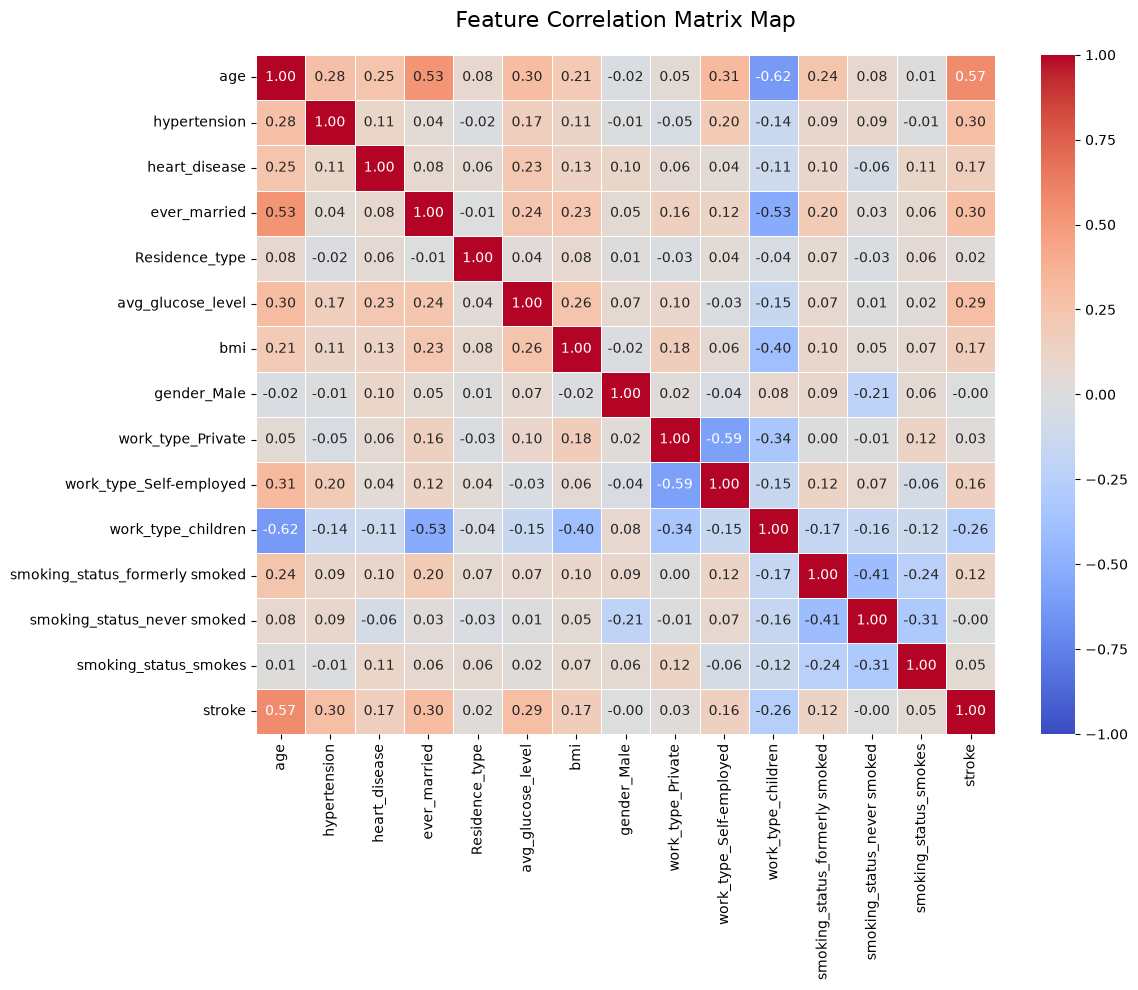

In [589]:
# Combine X_train and y_train temporarily to compute full correlations
df_corr_check = X_train.copy()
df_corr_check['stroke'] = y_train

# Compute the correlation matrix
corr_matrix = df_corr_check.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the correlation numbers
    fmt=".2f",          # Limit to 2 decimal places
    cmap="coolwarm",    # Blue is negative, Red is positive correlation
    vmin=-1, vmax=1,    # Set strict bounds for correlation coefficients
    linewidths=0.5
)
plt.title("Feature Correlation Matrix Map", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [590]:
# 1. Extract correlation values specifically for the target variable 'stroke'
stroke_corr = corr_matrix['stroke'].drop('stroke') # drop self-correlation

# 2. Convert to absolute values and create a sorted DataFrame
stroke_corr_df = pd.DataFrame({
    'Feature': stroke_corr.index,
    'Correlation': stroke_corr.values,
    'Absolute_Correlation': stroke_corr.abs().values
}).sort_values(by='Absolute_Correlation', ascending=False)

# 3. Print the neat, ordered list
print("--- Features Ranked by Absolute Correlation with Stroke ---")
print(stroke_corr_df[['Feature', 'Absolute_Correlation']].to_string(index=False))


--- Features Ranked by Absolute Correlation with Stroke ---
                       Feature  Absolute_Correlation
                           age          5.656316e-01
                  ever_married          2.996322e-01
                  hypertension          2.962386e-01
             avg_glucose_level          2.922101e-01
            work_type_children          2.594373e-01
                           bmi          1.738575e-01
                 heart_disease          1.702207e-01
       work_type_Self-employed          1.620323e-01
smoking_status_formerly smoked          1.178511e-01
         smoking_status_smokes          4.964289e-02
             work_type_Private          3.061065e-02
                Residence_type          2.484551e-02
                   gender_Male          1.906020e-16
   smoking_status_never smoked          1.882829e-16


In [591]:
selected_fetures = ['age','ever_married','hypertension', 'avg_glucose_level', 'work_type_children', 'bmi', 'heart_disease', 'work_type_Self-employed']

In [592]:
# Reassign X_train and X_test with ONLY these columns
X_train = X_train[selected_fetures]
X_test = X_test[selected_fetures]

In [593]:
#2. make sure the shape of X is (samples, features), and y is (samples, )
assert X_train.ndim == 2
assert X_test.ndim  == 2
assert y_train.ndim == 1

print("(samples, features): ", X_train.shape)
print("(samples,         ): ", y_train.shape)
print("(samples, features): ", X_test.shape)

(samples, features):  (396, 8)
(samples,         ):  (396,)
(samples, features):  (997, 8)


In [594]:
#3. perform cross validation with a selected set of models, to scope down which model is among the best

#3.1 specify the list of algorithms
#this is for classification
##Baselines
from sklearn.linear_model import LogisticRegression  #drawing a line based on linear regression but used for classification
from sklearn.naive_bayes import GaussianNB  #drawing a line based on probability

##Situational (but we don't use much)
from sklearn.neighbors import KNeighborsClassifier

##Complex
from sklearn.ensemble import RandomForestClassifier  #using trees to classify
from sklearn.svm import SVC  #drawing a line based on maximum distance
from sklearn.ensemble import GradientBoostingClassifier  #<<-------is the MOST complex
    #XGBoost but is not in sklearn, import XGBoost #<---most powerful algorithm for tabular data (not images, signal)

#any random_state you can use......up to you 
lr = LogisticRegression(max_iter=1000, random_state=999)
rf = RandomForestClassifier(random_state=999)
sv = SVC(random_state=999)

models = [lr, rf, sv]

from sklearn.preprocessing import StandardScaler # Added for scaling
from sklearn.pipeline import make_pipeline 

#3.2 perform cross validation using KFold
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits = 5, shuffle = True, random_state=999)

for model in models:
    pipeline = make_pipeline(StandardScaler(), model)
    score = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='accuracy')  #f1, recall, precision, accuracy

    print("Scores: ", score)  #out of 1 ; 1 means perfect accuracy
    model_name = model.__class__.__name__
    print(f"{model_name:<24} | Scores mean: {score.mean():.4f} | Std: {score.std():.4f}")    #lr, rf, sv

#when they are very close, 
    #how we choose?  we choose the simplest model...
    #what does simplest mean?  LogisticRegression is simplest, and SVM is the most complex....
    
#overfitting vs. underfitting
#overfitting means your model learns too much about the training set, 
    #so it cannot generalize to validation set or testing set (unseen data)
    #is NOT good - it means your model CANNOT GENERALIZE to unseen data (validation or test set)
    
#underfitting means your model just fail to see any patterns in the training set
    #this is easy: just look at score

Scores:  [0.7125     0.75949367 0.73417722 0.83544304 0.74683544]
LogisticRegression       | Scores mean: 0.7577 | Std: 0.0419
Scores:  [0.75       0.74683544 0.73417722 0.7721519  0.7721519 ]
RandomForestClassifier   | Scores mean: 0.7551 | Std: 0.0149
Scores:  [0.75       0.70886076 0.73417722 0.82278481 0.72151899]
SVC                      | Scores mean: 0.7475 | Std: 0.0400


In [595]:
#4. grid search to find the best version of that model
#remind you: grid search is BASICALLY same as cross validation but for the same model

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

base_pipeline = make_pipeline(StandardScaler(), LogisticRegression(random_state=999))

param_grid = dict()
param_grid['logisticregression__solver'] = ['newton-cg', 'lbfgs', 'liblinear']
param_grid['logisticregression__max_iter'] = [1000] # Forces it to scale steps for all solvers
param_grid['logisticregression__C'] = [0.01, 0.1, 1.0, 10.0] # Added regularization sweep for better tuning

#add more parameters here
#param_grid[parameter] = list of parameters to search

#refit means it will pick the best model, and fit again, so it means grid is already the best model after this line
grid = GridSearchCV(base_pipeline, param_grid, scoring="accuracy", cv=kfold, refit=True, return_train_score=True)
#scoring = f1, recall, precision, accuracy

#fit the grid, which will basically do cross validation across all combinatiosn, here we only have 3 comb
grid.fit(X_train, y_train)  #remember to use only training set here....

#print the best parameters and accuracy
print(grid.best_params_)
print(grid.best_score_)
# print(grid.cv_results_)

#this score is cross-validation score, basically the accuracy/precision/etc on the validation set


{'logisticregression__C': 10.0, 'logisticregression__max_iter': 1000, 'logisticregression__solver': 'newton-cg'}
0.7677531645569621


### Classification metrics

Let us study some classification metrics that are quite different from the $r^2$ or mean squared error that we see from the regression.  Let me define a confusion matrix that looks like this:

<code>
		 	    Actual
			    +	   -
Predicted +     TP     FP
          -     FN     TN
</code>

TP is defined as true positives, FP as false positives, FN as false negatives, and TN as true negatives.

#### Accuracy, Recall, Precision, F1

Accuracy is straightforward

$$ \text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}} $$

**Accuracy** is mostly avoided, unless your model is really balanced of both positives and negatives.  Instead, more useful classification metrics would be precision, recall, and f1-score

$$ \text{Precision} = \text{TP} / (\text{TP} + \text{FP}) $$

**Precision** is useful as metric when you want to prioritize removing false positive.  Example is search engine in which you do not want to return any search results that are "false positive"

$$ \text{Recall} = \text{TP} / (\text{TP} + \text{FN}) $$

**Recall** is useful as metric when you want to prioritize removing false negative.  Example is cancer detection in which you do not want to miss detecting any real positive (i.e., false negative).

$$ \text{F1} = 2 x \frac{\text{Precision} * \text{Recall}}{\text{Precision} + \text{Recall}} $$

**F1** is simply seeking a balance between Precision and Recall.  Also F1 is good metric when there is an uneven class distribution (large number of actual negatives)

sklearn provides a easy-to-use <code>**sklearn.metrics.classification_report**.</code> API that report these four metrics:

0.8333333333333334
0.75
1.0
0.8571428571428571
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



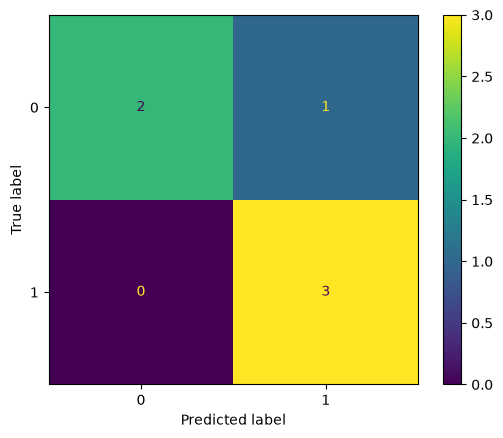

In [596]:
#confusion matrix 
'''
T = True, F = False
P = Positive, N = Negative
'''

''' 
                        Actual
                    P               N
             P     TP              FP
predict   
             N     FN              TN
'''

#0 here is negative
#1 here is positive

y     = [0, 0, 1, 1, 0, 1]
ypred = [1, 0, 1, 1, 0, 1]

#accuracy = (TP + TN) / (TP + FP + FN + TN)
#accuracy = 3 + 2  /  6 = 5 / 6 = 83%

#but accuracy is NOT good if your data is imbalanced (see actual y)

#recall, precision, f1-score
#recall = TP  / (TP + FN)
#recall = 3   / (3  + 0) = 100%  Recall is used when you don't like FN, e.g., critical - cancer, zombie, terrorists

#precision = TP / (TP + FP)
#precision = 3 /  (3 + 1) = 75% Precision is used when you don't like FP, e.g., search engine

#f1-score = 2 * ( (recall * precision) / (precision + recall) )
        #when precision and recall are both important.....
        #   2 * ( (1      * 0.75)     /   (0.75     +    1  ) )
        
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#if you want all in one table
from sklearn.metrics import classification_report

#if you want the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#format (ytrue, ypred)
print(accuracy_score(y, ypred))
print(precision_score(y, ypred))
print(recall_score(y, ypred))
print(f1_score(y, ypred))

print(classification_report(y, ypred))

cm = confusion_matrix(y, ypred)
cmp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])

cmp.plot()

#for regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


Let's explain the classification report a bit:

- <code>weight_avg</code> mutiplies score with the number of true labels in that class, favoring the majority label
#macro simply average, thus better for imbalanced dataset

- <code>macro_avg</code> 

- <code>support</code> refers to number of samples belonging to that class

Between precision or recall or f1?
- Use **recall** for dangerous stuffs - healthcare, security, fraud. You don't care about false positives too much (i.e., false alarm) because you want to always stay fully cautious.

- Use **precision** for search/identifying something - HR, search engine, etc.  You care a lot about false positive, i.e., you want to identify really good sample.

- Use **f1-score** - basically a good bet for almost all imbalanced dataset.

Final recommendations:
- in balanced dataset, just simply use <code>accuracy</code>
- in imbalanced dataset, use <code>macro avg f1-score</code> or <code>macro precision</code> or <code>macro recall</code>

## 7. Testing

In [597]:
pred_y = grid.predict(X_test)

print(pred_y)


[0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 1 0 1
 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 0 0 0 0
 0 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 1 1 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0
 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1
 1 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0
 1 1 0 0 0 1 1 0 0 0 1 1 

In [598]:
fake_y_test = np.random.randint(0, 2, size = (pred_y.shape))

In [599]:
accuracy_score(fake_y_test, pred_y)  #precision_score, recall_score, classification_report, confusion_matrix

0.4944834503510532

## 8. Analysis: Feature Importance

- Basically understanding which features are important for prediction
- Different algorithms have different way for feature importance
- For Logistic Regression, similar to Linear Regression, you can look at the coeffients/weights/slope

In [600]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some

In [601]:


# 1. Pull the trained logistic regression model out of the pipeline
best_model = grid.best_estimator_.named_steps['logisticregression']

# 2. Get the coefficients
coefficients = best_model.coef_[0]

# 3. Pair the coefficients with your X_train column names to see what matters
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("--- Final Model Coefficients ---")
print(feature_importance.to_string(index=False))


#predict LoanStatus, LoanAmount

--- Final Model Coefficients ---
                Feature  Coefficient
                    age     1.711437
     work_type_children     0.607434
           hypertension     0.425548
                    bmi     0.334530
           ever_married     0.261245
      avg_glucose_level     0.207753
          heart_disease    -0.035732
work_type_Self-employed    -0.104829


<Axes: ylabel='features'>

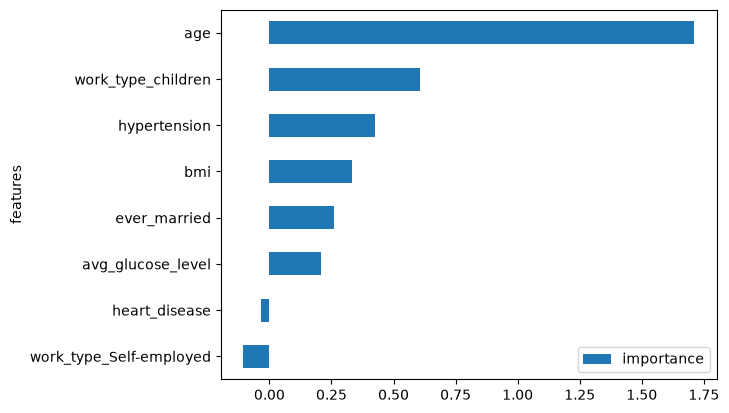

In [602]:
feature_importance = pd.DataFrame(selected_fetures, 
                                  columns=['features'])

best_logistic_model = grid.best_estimator_.named_steps['logisticregression']
feature_importance["importance"] = best_logistic_model.coef_[0]

feature_importance = feature_importance.sort_values(by = ['importance'], ascending=True)

feature_importance.plot.barh(x='features', y='importance')

## 9. Inference

In [603]:
import os
import pickle

# 1. Create the 'model' folder automatically if it doesn't exist yet
# (Otherwise Python will throw a FileNotFoundError)
os.makedirs('model', exist_ok=True)

# 2. Set the filename matching your project focus
filename = 'model/Stroke_Prediction_Grid.pkl' 

# 3. Save the entire pipeline grid (Includes scaling + optimal hyperparameters)
pickle.dump(grid, open(filename, 'wb'))
print(f"Successfully saved trained pipeline to {filename}")

# 4. Load the model back in for testing or deployment
loaded_grid = pickle.load(open(filename, 'rb'))
print("Model loaded successfully!")


Successfully saved trained pipeline to model/Stroke_Prediction_Grid.pkl
Model loaded successfully!


In [604]:
# Create a list matching your final selected features plus the target label 'stroke'
final_features = [
    'age', 'work_type_children', 'hypertension', 'bmi', 
    'ever_married', 'avg_glucose_level', 'heart_disease', 
    'work_type_Self-employed', 'stroke'
]

# View the values for the row at index 1
print(df_train[final_features].iloc[1])


age                         59.0
work_type_children         False
hypertension                 0.0
bmi                         30.2
ever_married                   1
avg_glucose_level          76.15
heart_disease                0.0
work_type_Self-employed    False
stroke                         1
Name: 75, dtype: object


In [605]:
sample_patient = np.array([[65.0, 0, 1, 28.5, 1, 115.0, 0, 0]])

# 2. Predict the discrete outcome (0 for no stroke, 1 for stroke risk)
predicted_stroke_status = loaded_grid.predict(sample_patient)
print("Predicted Stroke Class (0 or 1):", predicted_stroke_status)

Predicted Stroke Class (0 or 1): [1]


/Projects/python-project-starter/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
